# Regime-Switching Factor Investing with HMM: 2 vs 3 regimes

Runs the backtest in `src/` (HMM re-estimated every day on the previous 2707 trading days,
switching between factor strategies) with **3 regimes** (Bull → Carhart, Neutral → AQR,
Bear → Cash) and with **2 regimes** (Bull → Carhart, Bear → Cash), and compares them with SPY.

Data: SPY daily prices (Yahoo Finance) and Fama-French 5 factors + momentum (Kenneth French
data library). If the files are in `data/` they are read from there, otherwise they are
downloaded.

In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = os.path.abspath('..') if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
sys.path.insert(0, os.path.join(ROOT, 'src'))
os.makedirs(os.path.join(ROOT, 'results'), exist_ok=True)
os.chdir(os.path.join(ROOT, 'results'))     # charts and tables are saved here

from data_loader import fetch_data, calculate_features
from hmm_model import MarketHMM
from factor_analysis import fetch_ff_factors, analyze_performance
from backtester import run_backtest, get_state_map

## 1. Regimes in-sample, 2007–2017

HMM estimated on 2007–2017 with 2 and 3 states (75 EM iterations, as in `hmm_model.py`):
mean daily return and volatility of each regime, and Sharpe ratio of each factor strategy
inside each regime (`analyze_performance`).

In [2]:
df = calculate_features(fetch_data(start_date='2000-01-01', end_date='2024-01-01')).dropna()
train_df = df.loc['2007-01-01':'2017-12-31'].copy()
X_train = train_df[['Daily_Return', 'Volatility_10d_MSE']].values
ff_data = fetch_ff_factors('2007-01-01', '2017-12-31')

in_sample = {}
for k in [2, 3]:
    hmm = MarketHMM(n_components=k)
    hmm.train(X_train)
    labels = get_state_map(hmm, X_train)
    states = pd.Series(hmm.predict(X_train), index=train_df.index)
    regimes = states.map(labels)
    stats_k = (train_df.assign(Regime=regimes).groupby('Regime')
               .agg(Days=('Daily_Return', 'size'),
                    Avg_Daily_Return=('Daily_Return', 'mean'),
                    Avg_Volatility=('Volatility_10d_MSE', 'mean')))
    perf = analyze_performance(regimes, ff_data).set_index('State')
    in_sample[k] = (stats_k, perf)
    print(f"\n=== {k} regimes ===")
    print(stats_k.round(5))

Fetching data for SPY...
Fetching Fama-French factors...


Training HMM with 2 components...
Model converged: True

=== 2 regimes ===
        Days  Avg_Daily_Return  Avg_Volatility
Regime                                        
Bear     528          -0.00094         0.02036
Bull    2241           0.00070         0.00693
Training HMM with 3 components...


Model is not converging.  Current: 21191.20057410657 is not greater than 21191.36936959506. Delta is -0.1687954884910141


Model converged: True

=== 3 regimes ===
         Days  Avg_Daily_Return  Avg_Volatility
Regime                                         
Bear      244          -0.00203         0.02704
Bull     1413           0.00101         0.00518
Neutral  1112           0.00013         0.01113


In [3]:
for k in [2, 3]:
    print(f"\n=== {k} regimes: Sharpe ratio by regime ===")
    print(in_sample[k][1][['Market_Sharpe', 'Fama-French_Sharpe', 'Carhart_Sharpe',
                           'Value_Sharpe', 'AQR_Sharpe']].round(2))


=== 2 regimes: Sharpe ratio by regime ===
       Market_Sharpe  Fama-French_Sharpe  Carhart_Sharpe  Value_Sharpe  \
State                                                                    
Bear           -0.63               -0.62           -1.36         -0.63   
Bull            1.46                1.05            1.35          1.18   

       AQR_Sharpe  
State              
Bear        -1.14  
Bull         1.53  

=== 3 regimes: Sharpe ratio by regime ===
         Market_Sharpe  Fama-French_Sharpe  Carhart_Sharpe  Value_Sharpe  \
State                                                                      
Bear             -1.03               -1.16           -1.78         -1.13   
Bull              2.91                1.90            2.02          2.35   
Neutral           0.14                0.15            0.06          0.14   

         AQR_Sharpe  
State                
Bear          -1.74  
Bull           2.12  
Neutral        0.44  


## 2. Out-of-sample backtest, 2018–2023

The same backtest (`run_backtest`) with 3 and with 2 regimes. Each run re-estimates the HMM
about 1,500 times and takes a few minutes.

Loading data...
Fetching data for SPY...
Fetching Fama-French factors...


Starting backtest from 2018-01-01 (1509 trading days)...


  0%|          | 0/1509 [00:00<?, ?it/s]

  0%|          | 1/1509 [00:00<03:00,  8.35it/s]

  0%|          | 2/1509 [00:00<04:04,  6.17it/s]

...

100%|█████████▉| 1508/1509 [04:01<00:00,  5.70it/s]

100%|██████████| 1509/1509 [04:02<00:00,  5.55it/s]

100%|██████████| 1509/1509 [04:02<00:00,  6.24it/s]


--- Backtest Results (Jan 2018 - Present), 3 regimes ---
Dynamic Strategy CAGR: 15.48%
SPY Benchmark CAGR:    11.84%

Final Portfolio Value (Start=100):
Strategy: 236.85

Strategy Allocation Distribution:
Strategy
AQR        0.355202
Cash       0.339960
Carhart    0.304838
Name: proportion, dtype: float64



Saved plot to backtest_results_3_regimes.png


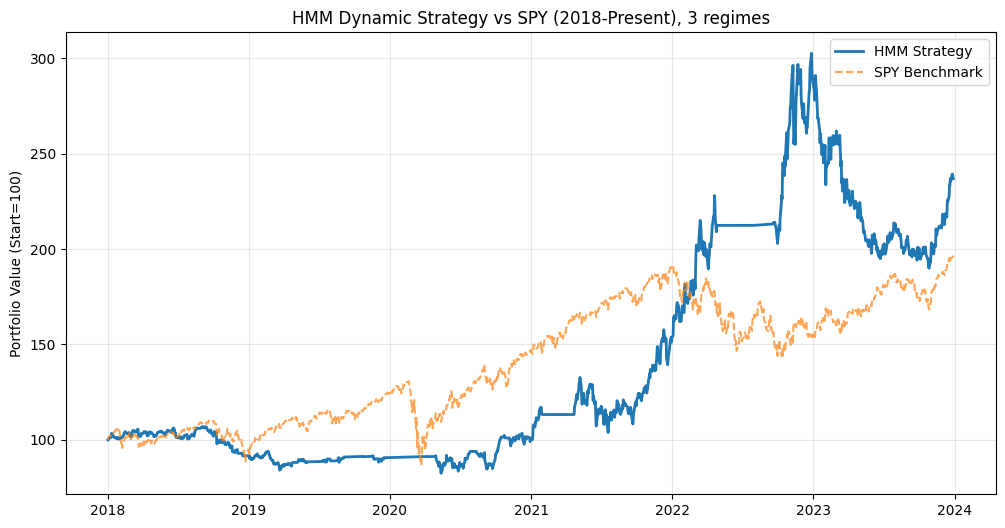

In [4]:
res3 = run_backtest(n_components=3)

Loading data...
Fetching data for SPY...
Fetching Fama-French factors...


Starting backtest from 2018-01-01 (1509 trading days)...


  0%|          | 0/1509 [00:00<?, ?it/s]

  0%|          | 2/1509 [00:00<03:16,  7.65it/s]

  0%|          | 4/1509 [00:00<03:19,  7.54it/s]

...

100%|█████████▉| 1505/1509 [03:17<00:00,  6.81it/s]

100%|█████████▉| 1507/1509 [03:17<00:00,  8.10it/s]

100%|█████████▉| 1508/1509 [03:17<00:00,  8.37it/s]

100%|██████████| 1509/1509 [03:17<00:00,  7.62it/s]


--- Backtest Results (Jan 2018 - Present), 2 regimes ---
Dynamic Strategy CAGR: 16.53%
SPY Benchmark CAGR:    11.84%

Final Portfolio Value (Start=100):
Strategy: 250.13

Strategy Allocation Distribution:
Strategy
Carhart    0.616302
Cash       0.383698
Name: proportion, dtype: float64

Saved plot to backtest_results_2_regimes.png


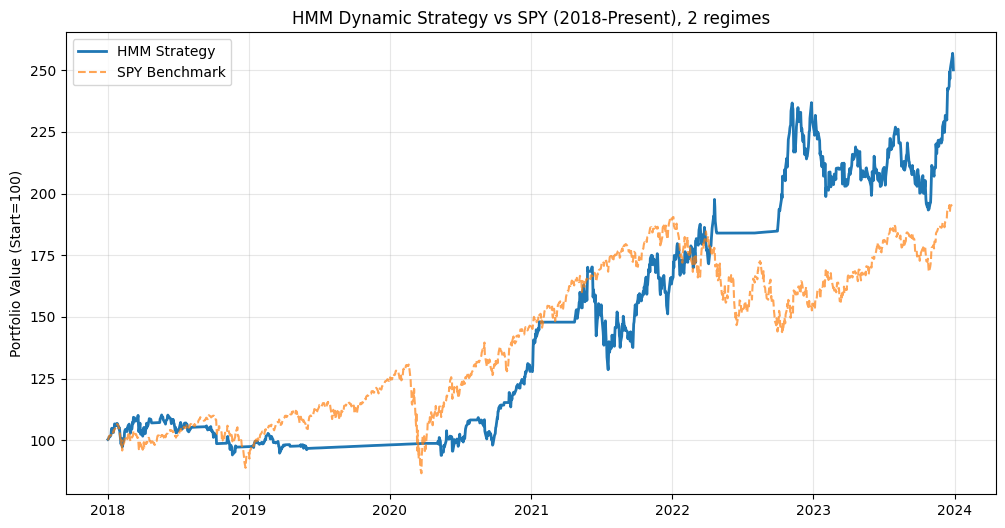

In [5]:
res2 = run_backtest(n_components=2)

## 3. Comparison

Daily returns of the two strategies and of SPY on the same dates. Sharpe ratio on returns in
excess of the risk-free rate (Fama-French RF), maximum drawdown, information ratio against
SPY, and the share of days in each strategy.

In [6]:
spy = fetch_data(start_date='2017-01-01')['Close'].pct_change()
rf = fetch_ff_factors('2017-01-01', '2025-01-01')
rf.columns = [c.strip() for c in rf.columns]
rf = rf['RF']

def daily_returns(res):
    pv = res['Portfolio_Value']
    r = pv.pct_change()
    r.iloc[0] = pv.iloc[0] / 100.0 - 1
    return r

returns = pd.DataFrame({'HMM, 3 regimes': daily_returns(res3),
                        'HMM, 2 regimes': daily_returns(res2)})
returns['SPY'] = spy.reindex(returns.index)
rf = rf.reindex(returns.index)

def metrics(r):
    years = len(r) / 252
    wealth = (1 + r).cumprod()
    ex = r - rf
    active = r - returns['SPY']
    return pd.Series({
        'CAGR %': 100 * (wealth.iloc[-1] ** (1 / years) - 1),
        'Volatility %': 100 * r.std() * np.sqrt(252),
        'Sharpe': ex.mean() / ex.std() * np.sqrt(252),
        'Max drawdown %': 100 * (wealth / wealth.cummax() - 1).min(),
        'Information ratio': active.mean() / active.std() * np.sqrt(252) if active.std() > 0 else np.nan,
        'Final value (start = 100)': 100 * wealth.iloc[-1],
    })

comparison = returns.apply(metrics).T
comparison.to_csv('comparison_2_vs_3_regimes.csv')
comparison.round(2)

Fetching data for SPY...
Fetching Fama-French factors...


,CAGR %,Volatility %,Sharpe,Max drawdown %,Information ratio,Final value (start = 100)
"HMM, 3 regimes",15.49,22.84,0.66,-37.21,0.13,236.85
"HMM, 2 regimes",16.54,20.18,0.76,-24.45,0.16,250.13
SPY,11.98,20.38,0.56,-33.72,NaN,196.94


In [7]:
allocation = pd.DataFrame({
    'HMM, 3 regimes': res3['Strategy'].value_counts(normalize=True),
    'HMM, 2 regimes': res2['Strategy'].value_counts(normalize=True)}).fillna(0)
(100 * allocation).round(1)

,"HMM, 3 regimes","HMM, 2 regimes"
Strategy,,
AQR,35.5,0.0
Carhart,30.5,61.6
Cash,34.0,38.4


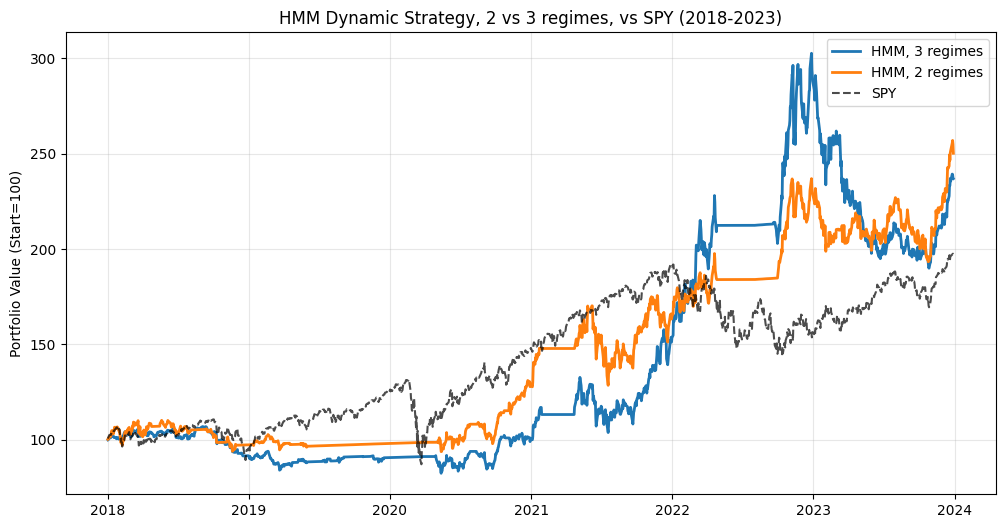

In [8]:
fig, ax = plt.subplots(figsize=(12, 6))
for name, style in [('HMM, 3 regimes', dict(linewidth=2)), ('HMM, 2 regimes', dict(linewidth=2)),
                    ('SPY', dict(linestyle='--', color='black', alpha=0.7))]:
    ax.plot(returns.index, 100 * (1 + returns[name]).cumprod(), label=name, **style)
ax.set_title('HMM Dynamic Strategy, 2 vs 3 regimes, vs SPY (2018-2023)')
ax.set_ylabel('Portfolio Value (Start=100)')
ax.grid(True, alpha=0.3)
ax.legend()
fig.savefig('comparison_2_vs_3_regimes.png', dpi=150, bbox_inches='tight')
plt.show()